# Modelos de redes neuronales

In [244]:
from joblib import dump, load
from keras.callbacks import EarlyStopping
from keras.layers import SimpleRNN, LSTM, Dense, Dropout
from keras.models import Model
from keras.models import Sequential
from keras.optimizers import Adam
from matplotlib.ticker import MaxNLocator
from scipy.stats import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.api import acf
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.stattools import q_stat
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM, SimpleRNN
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam, SGD
import datetime
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns
import statsmodels.api as sm
import sys
import tensorflow as tf
import tensorflow_probability as tfp
import warnings


In [245]:
# Load the dataset
file_path = 'river_aire_discharge_timeseries.csv'
data = pd.read_csv(file_path)

# Display the first few rows to understand the structure
data.head()
# Check if 'discharge_armley' exists in the columns
'discharge_armley' in data.columns


True

6/6 [==============================] - 0s 2ms/step
  Model      MAPE        MAE       RMSE         MSE        R2  \
0   RNN  0.252350   9.110001  17.270392  298.266427  0.558912   
1  LSTM  0.234093   8.754895  16.592538  275.312320  0.592858   
2   MLP  0.380453  10.637521  17.928762  321.440499  0.524641   

   Ljung-Box Test (p-value)  Jarque-Bera (p-value)  Training Time (s)  \
0                  0.036352          6.353513e-212           9.720654   
1                  0.453906          4.145922e-169          17.014398   
2                  0.021082          1.361567e-166           3.746354   

                                     Best Parameters  
0  {'units': 50, 'learning_rate': 0.001, 'batch_s...  
1  {'units': 50, 'learning_rate': 0.001, 'batch_s...  
2  {'units': 50, 'learning_rate': 0.01, 'batch_si...  
6/6 [==============================] - 0s 3ms/step


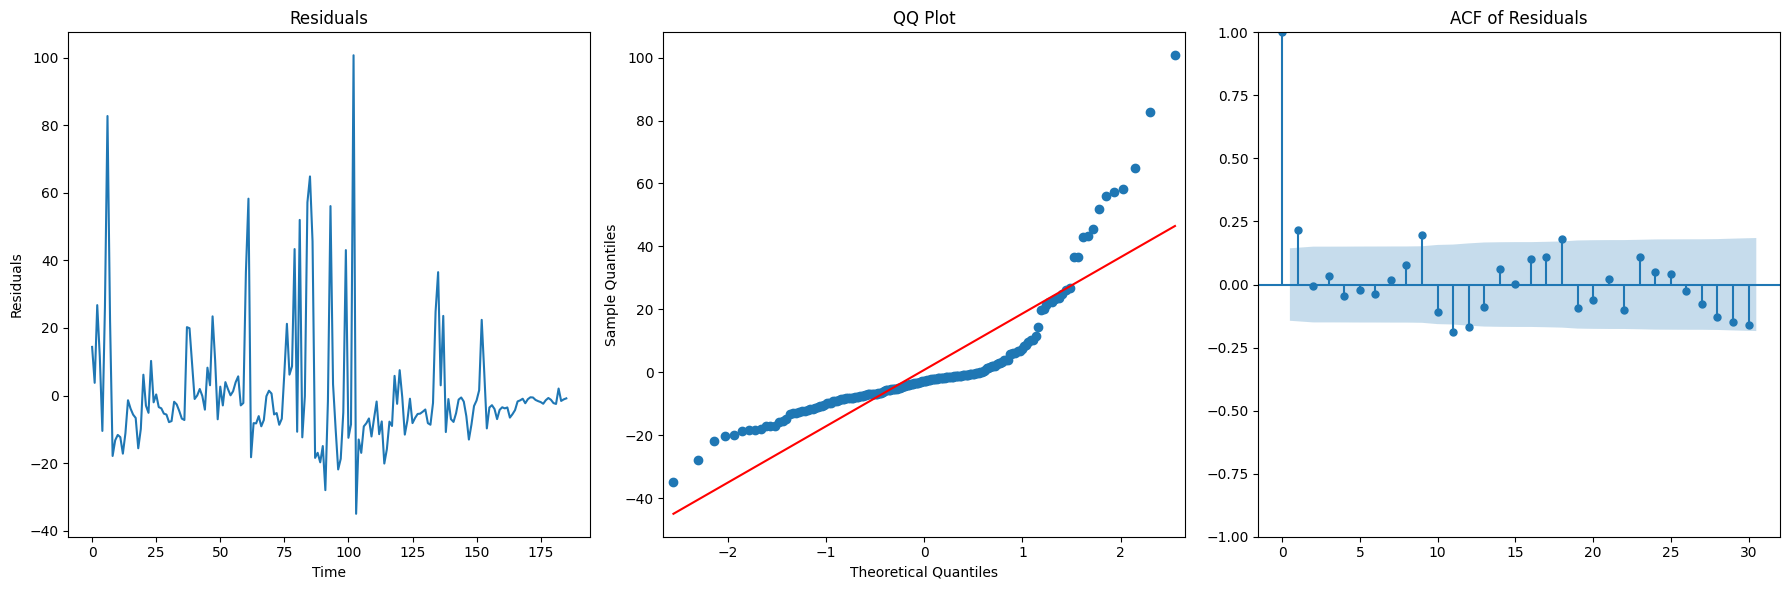

In [246]:
import pandas as pd
import numpy as np
import time
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import q_stat, acf
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

#preparar Datos
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data.set_index('Date', inplace=True)

#seleccionar columna de estudio
ts_data = data[['discharge_armley']].dropna()

# Escalar datos
scaler = MinMaxScaler(feature_range=(0, 1))
ts_scaled = scaler.fit_transform(ts_data)

# funcion para crear ventanas de entrenamiento de 30 días.
def create_sequences(data, sequence_length=30):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

# preparar ventana de entrenamientos
sequence_length = 30
X, y = create_sequences(ts_scaled, sequence_length)

# Dividir dataset training (70%), validation (15%) and testing (15%)
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))
X_train, X_val, X_test = X[:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size + val_size], y[train_size + val_size:]

# Funcion de construcción de modelos
def build_model(model_type, input_shape, units=50, learning_rate=0.001, dropout_rate=0.2):
    model = Sequential()
    if model_type == 'RNN':
        model.add(SimpleRNN(units, input_shape=input_shape))
    elif model_type == 'LSTM':
        model.add(LSTM(units, input_shape=input_shape))
    elif model_type == 'MLP':
        model.add(Dense(units, activation='relu', input_shape=(input_shape[0],)))
    model.add(Dropout(dropout_rate))  # Add dropout layer for regularization
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Busqueda por rejilla optimización
units_options = [50, 100]
learning_rate_options = [0.001, 0.01]
batch_size_options = [16, 32]
dropout_rate_options = [0.2, 0.3]

# Inicializar el escalador y preparar los datos de entrenamiento y prueba
scaler = MinMaxScaler(feature_range=(0, 1))
ts_scaled = scaler.fit_transform(ts_data)

# Ajustar el DataFrame de resultados
results = {
    "Model": [],
    "MAPE": [],
    "MAE": [],
    "RMSE": [],
    "MSE": [],
    "R2": [],
    "Ljung-Box Test (p-value)": [],
    "Jarque-Bera (p-value)": [],
    "Training Time (s)": [],
    "Best Parameters": []
}

# Modificar la función de evaluación para incluir tiempo de entrenamiento
def evaluate_model(model, X_test, y_test, name, best_params, start_time):
    y_pred = model.predict(X_test)
    y_pred_inverse = scaler.inverse_transform(y_pred)
    y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Calcular métricas
    mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
    mse = mean_squared_error(y_test_inverse, y_pred_inverse)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_inverse, y_pred_inverse)
    mape = mean_absolute_percentage_error(y_test_inverse, y_pred_inverse)

    # Calcular el tiempo de entrenamiento
    training_time = time.time() - start_time

    # Calcular pruebas estadísticas de normalidad e independencia de errores
    residuals = y_test_inverse - y_pred_inverse
    ljung_box_pval = acorr_ljungbox(residuals.flatten(), lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    jb_pval = jarque_bera(residuals.flatten())[1]

    # Agregar resultados al diccionario
    results['Model'].append(name)
    results['MAPE'].append(mape)
    results['MAE'].append(mae)
    results['RMSE'].append(rmse)
    results['MSE'].append(mse)
    results['R2'].append(r2)
    results['Ljung-Box Test (p-value)'].append(ljung_box_pval)
    results['Jarque-Bera (p-value)'].append(jb_pval)
    results['Training Time (s)'].append(training_time)
    results['Best Parameters'].append(best_params)

# Realizar la búsqueda por rejilla y evaluar los modelos
models = ['RNN', 'LSTM', 'MLP']
for model_type in models:
    best_mse = float("inf")
    best_params = {}

    for units in units_options:
        for lr in learning_rate_options:
            for batch_size in batch_size_options:
                for dropout in dropout_rate_options:
                    input_shape = (X_train.shape[1], X_train.shape[2]) if model_type != 'MLP' else (X_train.shape[1],)
                    model = build_model(model_type, input_shape, units, lr, dropout)

                    # Medir tiempo de inicio del entrenamiento
                    start_time = time.time()

                    # Entrenar el modelo
                    early_stopping = EarlyStopping(monitor='val_loss', patience=5)
                    model.fit(X_train, y_train, epochs=50, batch_size=batch_size, 
                              validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)

                    # Evaluar el modelo en conjunto de validación
                    y_pred_val = model.predict(X_val)
                    mse = mean_squared_error(y_val, y_pred_val)

                    # Guardar el mejor modelo
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {
                            "units": units,
                            "learning_rate": lr,
                            "batch_size": batch_size,
                            "dropout_rate": dropout
                        }
                        best_model = model

    # Evaluar y almacenar resultados del mejor modelo
    evaluate_model(best_model, X_test, y_test, model_type, best_params, start_time)

# Convertir resultados a DataFrame
results_Redes = pd.DataFrame(results)
print(results_Redes)

# Mostrar las gráficas de los residuales
y_pred_scaled = best_model.predict(X_test)
residuals = scaler.inverse_transform(y_test.reshape(-1, 1)) - scaler.inverse_transform(y_pred_scaled)

# Graficar los residuales
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico de residuales
axes[0].plot(residuals)
axes[0].set_title("Residuals")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Residuals")

# QQ plot
qqplot(residuals.flatten(), line='s', ax=axes[1])
axes[1].set_title("QQ Plot")

# ACF plot
plot_acf(residuals.flatten(), lags=30, ax=axes[2])
axes[2].set_title("ACF of Residuals")

plt.tight_layout()
plt.show()


Los residuos no parecen ser normales ni tener media cero. 

# BESN

La base del BESN es el ESN, es un tipo de red neuronal que consta de una capa de entrada, una capa del reservorio que y una caoa de salida

Para la entrada dada, el estado del reservorio x y la salida deseada t, la suma de cuadrados del error

$E_D = \frac{1}{2} \sum_{i=1}^n \left( f(z_i; W^{\text{out}}) - t_i \right)^2$

se selecciona como la funcion de velaución de rendiemiento.

el término de regularización  se introduce en la función de evaluación del rendimiento en base a la técnica de regularización. $E_W = \frac{1}{2} \sum_{i=1}^L \left( W^{\text{out}} \right)^2$

la función de error se puede obtener de la siguiente manera:

$F(W^{\text{out}}) = \beta E_D + \alpha E_W$

Donde alpha y beta son hiperparametros de y n es el tamaño de la muestra









En el proceso de entrenamiento los datos se muestran indicados de la siguiente manera: 
$\{ (u_i, t_i) \mid i = 1, \dots, T \}$

Despues de haber establecer al entrada en el estado del reservorio x y la salida deseada en t, podemos obtener una serie de pares de datos 

$\{ (\mathbf{z}_i, t_i) \mid i = 1, \dots, n \}$

Luego la matriz de pesos de salida se estima mediante el método bayesiano



La teoría Bayesiana se centra en la distribución de probabilidad de los pesos.  El proceso de aprendizaje convencional comienza con una distribución de probabilidad previa adecuada de los pesos de salida Pwout, antes de que se obtengan los datos observados. Dado el conjunto de muestras, se utiliza el teorema de Bayes para escribir una expresión de la distribución de probabilidad posterior para los pesos de salida de la siguiente manera: 

$$
p(\mathbf{W}^{\text{out}} \mid D) = \frac{p(D \mid \mathbf{W}^{\text{out}}) \, p(\mathbf{W}^{\text{out}})}{p(D)}
$$

donde $$
p(\mathbf{W}^{\text{out}} \mid D)$$  es la función de verosimilitud; el denominador p(D) es 
un factor de normalización.

$$
p(\mathbf{W}^{\text{out}} \mid D) = \frac{1}{Z_M(\alpha, \beta)} \exp(-\beta E_D - \alpha E_W) = \frac{1}{Z_M} \exp[-F(\mathbf{W}^{\text{out}})]
$$

donde ZM(α,β) no están relacionado con Wout Por lo tanto, los pesos óptimos de salida de la red se pueden entrenar minimizando la función de error F(Wout)  o maximizando la distribución posterior  $p(\mathbf{W}^{\text{out}} \mid D)$





La BESN tiene dos hiperparámetros, de los cuales αalpha controla la distribución previa de los pesos de salida, y betaβ controla la distribución 
de la función de verosimilitud. Basado en la aproximación de Laplace,  la distribución de probabilidad posterior de los pesos de salida de la red se puede escribir aproximadamente como:

$p(w \mid D) \approx p(w \mid \alpha^*, \beta^*, D)$

Donde \alpha^* y \beta^* son los valores óptimos. Por lo tanto, se necesitan alpha*α∗ y beta*β∗ para maximizar la probabilidad posterior de los pesos de salida. Según , los valores óptimos de los hiperparámetros son: 
$$
\alpha^* = \frac{\gamma}{2 E_W}, \quad \beta^* = \frac{n - \gamma}{2 E_D} \tag{7}
$$

donde
$$
\gamma = \sum_{i=1}^L \frac{\lambda_i}{\lambda_i + \alpha}
$$

y λi es el valor propio de la matriz Hessiana de la función de error 
EDE_DED.


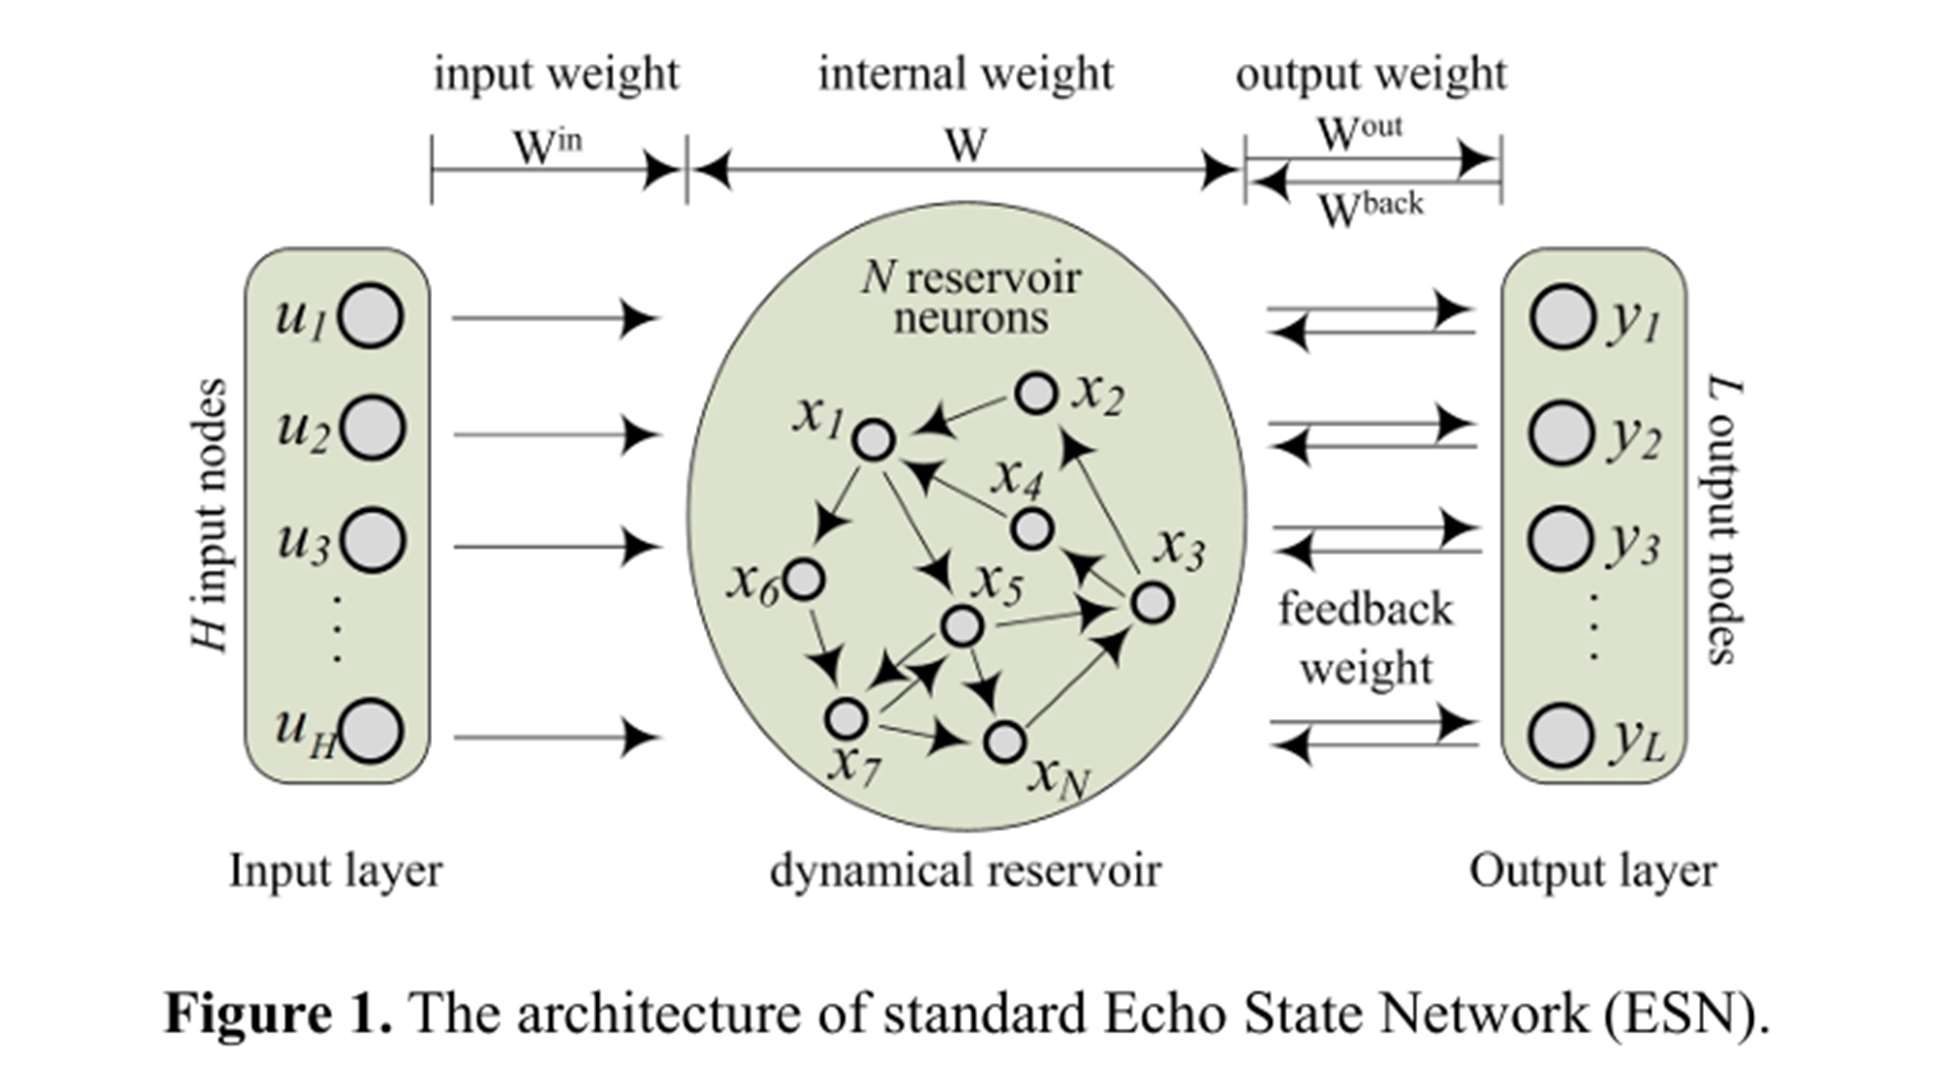

In [247]:
from IPython.display import Image, display

# Sinteis del modelo
image_path = "image.png"
display(Image(filename=image_path))

In [248]:
file_path = 'river_aire_discharge_timeseries.csv'
df = pd.read_csv(file_path)

# Copiar la columna 'Price' a una nueva variable
df = df['discharge_armley'].copy()

# Crear el escalador
scaler = MinMaxScaler(feature_range=(0, 1))

# Escalar los datos
df_scaled = scaler.fit_transform(df.values.reshape(-1, 1)).flatten()

# Convertir a DataFrame si es necesario
df_discharge_scaled = pd.DataFrame(df_scaled, columns=['discharge_scaled'])

print(df_discharge_scaled)

      discharge_scaled
0             0.021887
1             0.033704
2             0.037096
3             0.033863
4             0.026868
...                ...
1259          0.007684
1260          0.025066
1261          0.010970
1262          0.008691
1263          0.008320

[1264 rows x 1 columns]


# BESN

In [249]:
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras.layers import Layer, Input
from tensorflow.keras.models import Model
import numpy as np

# Definición de la Echo State Layer
class EchoStateLayer(Layer):
    def __init__(self, units, spectral_radius=0.9, leaky_rate=1.0, **kwargs): 
        super(EchoStateLayer, self).__init__(**kwargs)
        self.units = units
        self.spectral_radius = spectral_radius
        self.leaky_rate = leaky_rate

    def build(self, input_shape):
        initial_weights = np.random.uniform(-0.5, 0.5, size=(self.units, self.units)).astype(np.float32)
        max_eigenvalue = np.max(np.abs(np.linalg.eigvals(initial_weights)))
        self.reservoir_weights = self.add_weight(
            shape=(self.units, self.units),
            initializer=tf.keras.initializers.Constant(initial_weights / max_eigenvalue * self.spectral_radius),
            trainable=False,
            name='reservoir_weights'
        )
        
        self.input_weights = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer=tf.keras.initializers.RandomUniform(-0.5, 0.5),
            trainable=False,
            name='input_weights'
        )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        time_steps = tf.shape(inputs)[1]
        state = tf.zeros((batch_size, self.units))

        # Utilizar tf.TensorArray para gestionar estados sin problemas de grafo
        states = tf.TensorArray(dtype=tf.float32, size=time_steps)

        for t in range(time_steps):
            current_input = inputs[:, t, :]
            state_update = tf.nn.tanh(tf.matmul(current_input, self.input_weights) + tf.matmul(state, self.reservoir_weights))
            state = (1 - self.leaky_rate) * state + self.leaky_rate * state_update
            states = states.write(t, state)

        # Apilar todos los estados para obtener una salida con 3 dimensiones
        return tf.transpose(states.stack(), perm=[1, 0, 2])  # shape (batch_size, time_steps, units)

# Crear una función para construir el modelo
def create_bayesian_ESN(input_shape, reservoir_units, output_dim, prior_stddev, alpha, beta):
    inputs = Input(shape=input_shape)
    esn = EchoStateLayer(reservoir_units, spectral_radius=0.9, leaky_rate=0.5)(inputs)
    esn = esn[:, -1, :]  # Tomar el último estado (shape (batch_size, units))
    outputs = BayesianDense(output_dim, prior_stddev)(esn)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss=bayesian_loss(beta=beta, alpha=alpha))
    return model


In [250]:
def create_sliding_windows(data, window_sizes, step_size, taus): # Función para crear las ventanas de tiempo
    result_dict = {}  # Diccionario para almacenar los DataFrames por `window_size`
    
    for w in window_sizes:    
        all_combined_dfs = []  # Para almacenar resultados combinados para el tamaño de ventana actual

        for t in taus:
            X, y = [], []
            for i in range(0, len(data) - (w + t), step_size):
                # Ventana de entrada
                X.append(data[i:i + w])
                
                # Extraer el valor específico de `tau` pasos adelante
                future_value = data[i + w + t - 1]  # -1 para índice cero
                y.append([future_value])  # Guarda solo el valor correspondiente a `tau`
            
            # Convertir X e y en DataFrames
            df_X = pd.DataFrame(np.array(X).squeeze())  # Asegura que sea un array 2D (n, w)
            df_y = pd.DataFrame(y, columns=[f'Tau_{t}'])  # Solo la columna para el tau actual
            
            # Combinar los DataFrames de X e y
            df_combined = pd.concat([df_X, df_y], axis=1)
            all_combined_dfs.append(df_combined)
        
        # Combina todos los resultados para el tamaño de ventana actual
        final_df = pd.concat(all_combined_dfs, axis=0).reset_index(drop=True)
        
        # Guarda en el diccionario
        result_dict[f'Window_{w}'] = final_df
    
    return result_dict

In [251]:
def segment_data_by_window(df, train_size, val_size, test_size): # Función para segmentar los datos en train, validation y test
    train_data, val_data, test_data = [], [], []
    i = 0
    while i + train_size + val_size + test_size <= len(df):
        # Segmento de entrenamiento
        train_data.append(df.iloc[i:i + train_size])
        # Segmento de validación
        val_data.append(df.iloc[i + train_size:i + train_size + val_size])
        # Segmento de prueba
        test_data.append(df.iloc[i + train_size + val_size:i + train_size + val_size + test_size])
        
        # Mover el índice al siguiente bloque
        i += train_size + val_size + test_size
    
    # Concatenar los segmentos de datos
    train_data = pd.concat(train_data).reset_index(drop=True)
    val_data = pd.concat(val_data).reset_index(drop=True)
    test_data = pd.concat(test_data).reset_index(drop=True)

    return train_data, val_data, test_data,df


In [252]:
class ManualR2Callback(Callback): #Calculo del r2 como métrica personalizada e incluirse en el History. 
    def __init__(self, X_val, y_val):
        super(ManualR2Callback, self).__init__()
        self.X_val = X_val
        self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        val_predictions = self.model.predict(self.X_val).flatten()
        val_r2 = r2_score(self.y_val, val_predictions)
        print(f"Epoch {epoch + 1}: Validation R2 Score = {val_r2:.4f}")

In [253]:
def select_best_model(model, model_type, neurons, dropout, batch_size, epochs, X_train, y_train, X_val, y_val, X_test, y_test, return_history, window_size, tau,serie):
    # Crear subdirectorio para el tamaño de ventana específico
    model_dir = f'modelos_{serie}/models_window_{window_size}_tau_{tau}'
    os.makedirs(model_dir, exist_ok=True)

    # Nombre lógico del archivo basado en los parámetros del modelo
    base_filename = f'{model_type}_{neurons}neurons_{dropout}dropout_batch{batch_size}_window{window_size}_tau{tau}'
    model_filename = os.path.join(model_dir, f'{base_filename}_best_model.keras')
    history_filename = os.path.join(model_dir, f'{base_filename}_history.joblib')
    
    # Callback para guardar el mejor modelo
    save_best = ModelCheckpoint(model_filename, monitor='val_mean_squared_error', verbose=1,
                                save_best_only=True, mode='min', save_weights_only=False)
    
    # Callback para calcular R2 manual al final de cada época
    manual_r2_callback = ManualR2Callback(X_val, y_val)
    
    # Variable para decidir si entrenar un nuevo modelo
    load_new_model = True
    best_val_mse = float('inf')
    existing_epochs = 0

    # Cargar historial previo si existe y verificar el val_mean_squared_error y las épocas
    if os.path.exists(history_filename):
        history_data = load(history_filename)
        existing_epochs = len(history_data['loss'])
        if 'val_mean_squared_error' in history_data:
            best_val_mse = min(history_data['val_mean_squared_error'])

        # Comprobar si el modelo existente tiene mejor val_mean_squared_error y mayor o igual épocas
        if best_val_mse <= history_data['val_mean_squared_error'][-1] and existing_epochs >= epochs:
            print(f"Modelo previo con mejor val_mean_squared_error ({best_val_mse}) y más épocas ({existing_epochs}). No se reemplazará.")
            load_new_model = False
        else:
            print(f"Se entrenará con {epochs} y actualizará si mejora el rendimiento.")

    # Entrenar y guardar el modelo si se requiere uno nuevo
    if load_new_model:
        # Entrenar el modelo y guardar el historial
        history = model.fit(x=X_train, y=y_train, batch_size=batch_size, epochs=epochs,
                            verbose=2, callbacks=[save_best, manual_r2_callback], validation_data=(X_val, y_val),
                            shuffle=True)
        
        # Guardar el historial en el archivo .joblib
        history_data = history.history
        
        # Evaluar el mejor modelo en el conjunto de prueba
        test_results = model.evaluate(X_test, y_test, verbose=0)
        test_metrics = {f'test_{metric}': value for metric, value in zip(model.metrics_names, test_results)}
        
        # Agregar métricas de prueba al historial
        for metric, value in test_metrics.items():
            history_data[metric] = [value]
        
        # Guardar el historial con las métricas de prueba
        dump(history_data, history_filename)
        print(f"El entrenamiento se ha completado y el historial se guardó en '{history_filename}'")

    # Verificar y cargar el mejor modelo guardado
    if os.path.exists(model_filename):
        print(f"El mejor modelo guardado está en '{model_filename}'")
        best_model = load_model(model_filename)
    else:
        print("No se encontró un modelo previo con mejor val_mean_squared_error.")
        best_model = model

    # Retornar el mejor modelo y el historial, si es necesario
    if return_history:
        return best_model, history_data
    else:
        return best_model

In [254]:
# Extraer valores de la columna 'discharge_armley'

values = ts_data['discharge_armley'].values.reshape(-1, 1)  # Asegúrate de que los valores sean 2D


# Definir proporciones para dividir los datos
train_size = int(len(values) * 0.7)
val_size = int(len(values) * 0.15)

# Separar los datos
train_data = values[:train_size]
val_data = values[train_size:train_size + val_size]
test_data = values[train_size + val_size:]

print(f"Train data length: {len(train_data)}")
print(f"Validation data length: {len(val_data)}")
print(f"Test data length: {len(test_data)}")

Train data length: 884
Validation data length: 189
Test data length: 191


In [255]:
def get_XY(data, time_steps):
    X, Y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        Y.append(data[i + time_steps])
    return np.array(X), np.array(Y)

# Definir el número de pasos de tiempo
time_steps = 7

# Crear ventanas deslizantes para cada conjunto
trainX, trainY = get_XY(train_data, time_steps)
valX, valY = get_XY(val_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

# Ajustar la forma para el modelo ESN
trainX = trainX.reshape((trainX.shape[0], trainX.shape[1], 1))
valX = valX.reshape((valX.shape[0], valX.shape[1], 1))
testX = testX.reshape((testX.shape[0], testX.shape[1], 1))

trainY = trainY.reshape(-1, 1)
valY = valY.reshape(-1, 1)
testY = testY.reshape(-1, 1)

# Verificar las formas
print(f"trainX shape: {trainX.shape}, trainY shape: {trainY.shape}")
print(f"valX shape: {valX.shape}, valY shape: {valY.shape}")
print(f"testX shape: {testX.shape}, testY shape: {testY.shape}")



trainX shape: (877, 7, 1), trainY shape: (877, 1)
valX shape: (182, 7, 1), valY shape: (182, 1)
testX shape: (184, 7, 1), testY shape: (184, 1)


In [256]:
# Definir los rangos de parámetros a explorar
reservoir_units_list = [100, 200, 500]
prior_stddev_list = [0.1, 0.25, 0.5]
alpha_list = [0.01, 0.1, 0.5]
beta_list = [0.01, 0.1, 0.5]

# Variables para guardar el mejor modelo y el mejor error
best_mse = float('inf')
best_params = None
best_model = None

# Ciclo para iterar sobre todos los parámetros
for reservoir_units in reservoir_units_list:
    for prior_stddev in prior_stddev_list:
        for alpha in alpha_list:
            for beta in beta_list:
                # Crear el modelo BESN con los parámetros actuales
                model_ESN = create_bayesian_ESN(
                    input_shape=(trainX.shape[1], trainX.shape[2]),
                    reservoir_units=reservoir_units,
                    output_dim=1,
                    prior_stddev=prior_stddev,
                    alpha=alpha,
                    beta=beta
                )
                 # Crear dataset con drop_remainder=True
                train_dataset = Dataset.from_tensor_slices((trainX, trainY)).batch(32, drop_remainder=True)
                val_dataset = Dataset.from_tensor_slices((valX, valY)).batch(32, drop_remainder=True)

                # Entrenar el modelo
                model_ESN.fit(train_dataset, epochs=20, validation_data=val_dataset, verbose=0)

                # Realizar predicciones en el conjunto de validación
                val_predict = model_ESN.predict(valX)

                # Calcular el MSE en el conjunto de validación
                mse = mean_squared_error(valY, val_predict)

                # Verificar si es el mejor modelo hasta ahora
                if mse < best_mse:
                    best_mse = mse
                    best_params = (reservoir_units, prior_stddev, alpha, beta)
                    best_model = model_ESN

                print(f"Reservoir Units: {reservoir_units}, Prior Stddev: {prior_stddev}, Alpha: {alpha}, Beta: {beta} => Validation MSE: {mse:.4f}")

# Mostrar los mejores parámetros
print(f"Mejor modelo con MSE: {best_mse:.4f}")
print(f"Reservoir Units: {best_params[0]}, Prior Stddev: {best_params[1]}, Alpha: {best_params[2]}, Beta: {best_params[3]}")


6/6 [==============================] - 0s 3ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.01, Beta: 0.01 => Validation MSE: 249.7475
6/6 [==============================] - 0s 3ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.01, Beta: 0.1 => Validation MSE: 164.9912
6/6 [==============================] - 0s 3ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.01, Beta: 0.5 => Validation MSE: 108.8535
6/6 [==============================] - 0s 3ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.1, Beta: 0.01 => Validation MSE: 266.7669
6/6 [==============================] - 0s 3ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.1, Beta: 0.1 => Validation MSE: 248.9261
6/6 [==============================] - 0s 3ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.1, Beta: 0.5 => Validation MSE: 212.2305
6/6 [==============================] - 0s 3ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.5, Beta: 0.01 => Validation MSE: 251.9120


A partir del análisis de los resultados de busqueda por reijlla. Evidenciamos que altos Beta, generan bajos errores. Bajos alphas también generan bajos errores en las predicciones. Prior_stddev, bajos permite tener una mayor estabilidad en el reservorio. Por lo tanto, iniciamos la creación de nuestro modelo BSEN con esta lógica de parámetros y lo ajustamos en el conjunto de entrenamiento y verificamos en el conjunto de validación. Con las épocas suficientes para alcanzar un error mínimo.

In [265]:
# Parámetros de ejemplo para crear el modelo
model_BESN = create_bayesian_ESN(
    input_shape=(7, 1),
    reservoir_units=500,
    output_dim=1,
    prior_stddev=0.1,
    alpha=0.01, #para darle poca relevancia a los erorres en los pesos iniciales
    beta=0.5 # alto darle mayor ponderación al error de los datos. 
)

In [266]:
from tensorflow.data import Dataset

# Crear datasets con drop_remainder=False
train_dataset = Dataset.from_tensor_slices((trainX, trainY)).batch(8, drop_remainder=False)
val_dataset = Dataset.from_tensor_slices((valX, valY)).batch(8, drop_remainder=False)

# Entrenar usando el dataset
model_BESN.fit(train_dataset, validation_data=val_dataset, epochs=100,batch_size=64)


Epoch 1/100


110/110 [==============================] - 2s 7ms/step - loss: 260.5416 - val_loss: 88.8602
Epoch 2/100
110/110 [==============================] - 0s 4ms/step - loss: 222.3638 - val_loss: 96.0142
Epoch 3/100
110/110 [==============================] - 0s 4ms/step - loss: 208.4648 - val_loss: 83.4516
Epoch 4/100
110/110 [==============================] - 0s 4ms/step - loss: 194.6099 - val_loss: 76.3067
Epoch 5/100
110/110 [==============================] - 1s 7ms/step - loss: 188.9329 - val_loss: 72.2767
Epoch 6/100
110/110 [==============================] - 1s 5ms/step - loss: 179.2549 - val_loss: 80.6856
Epoch 7/100
110/110 [==============================] - 1s 5ms/step - loss: 176.3662 - val_loss: 64.1132
Epoch 8/100
110/110 [==============================] - 1s 5ms/step - loss: 170.3522 - val_loss: 63.2169
Epoch 9/100
110/110 [==============================] - 1s 5ms/step - loss: 163.7188 - val_loss: 61.5401
Epoch 10/100
110/110 [==============================] - 1s 5ms/step - loss: 

In [267]:
train_predict_ESN = model_BESN.predict(trainX)
test_predict_ESN = model_BESN.predict(testX)
val_predict_ESN = model_BESN.predict(valX)

6/6 [==============================] - 0s 7ms/step


In [268]:
import matplotlib.pyplot as plt

def plot_combined_predictions(trainY, valY, testY, train_predict_ESN, val_predict_ESN, test_predict_ESN):
    # Crear las listas combinadas de los valores originales y las predicciones
    original_data = list(trainY) + list(valY) + list(testY)
    predictions = list(train_predict_ESN) + list(val_predict_ESN) + list(test_predict_ESN)
    
    # Determinar las posiciones de las divisiones
    train_division = len(trainY)
    val_division = train_division + len(valY)
    
    # Crear la gráfica
    plt.figure(figsize=(12, 6))
    plt.plot(original_data, label="Valores Originales", color='blue')
    plt.plot(predictions, label="Predicciones ESN", color='orange', linestyle='--')

    # Líneas divisorias entre entrenamiento, validación y prueba
    plt.axvline(x=train_division, color='green', linestyle='--', label='División Entrenamiento-Validación')
    plt.axvline(x=val_division, color='red', linestyle='--', label='División Validación-Prueba')

    # Etiquetas y leyenda
    plt.xlabel("Índice de tiempo")
    plt.ylabel("Valor")
    plt.title("Valores Originales y Predicciones")
    plt.legend()
    plt.show()


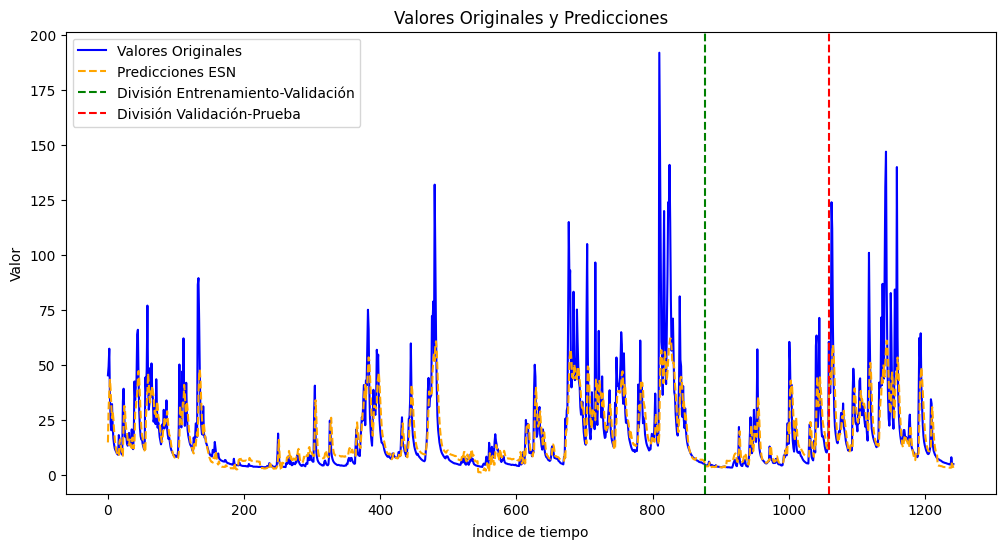

In [269]:
plot_combined_predictions(trainY, valY, testY, train_predict_ESN, val_predict_ESN, test_predict_ESN)

In [270]:
import pandas as pd
import numpy as np
import time
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score

def calculate_errors(y_true, y_pred, set_name):
    # Asegurar que los datos sean arrays de numpy y aplanar a 1D
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Asegurar que ambas variables tengan el mismo tamaño
    min_length = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:min_length], y_pred[:min_length]
    
    # Medir el tiempo de procesamiento
    start_time = time.time()
    
    # Calcular métricas de error
    mape = mean_absolute_percentage_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Calcular residuos
    residuals = y_true - y_pred

    # Prueba de Ljung-Box (verifica autocorrelación de residuos)
    ljung_box_p_value = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].iloc[0]

    # Prueba de Jarque-Bera (verifica normalidad de residuos)
    jb_p_value = jarque_bera(residuals)[1]  # índice [1] para obtener solo el p-value
    
    # Calcular el tiempo de procesamiento
    processing_time = time.time() - start_time

    # Crear un diccionario con los resultados
    results = {
        "Set": set_name,
        "MAPE": mape,
        "MAE": mae,
        "RMSE": rmse,
        "MSE": mse,
        "R2": r2,
        "Ljung-Box test (p-value)": ljung_box_p_value,
        "Jarque-Bera (p-value)": jb_p_value,
        "Processing Time (s)": processing_time
    }
    
    return results

# Convertir predicciones a una sola dimensión si es necesario
train_predict_ESN = train_predict_ESN.flatten()
test_predict_ESN = test_predict_ESN.flatten()
val_predict_ESN = val_predict_ESN.flatten()

# Calcular los errores para cada conjunto y almacenar en un DataFrame
results = []
results.append(calculate_errors(y_true=trainY, y_pred=train_predict_ESN, set_name="Train"))
results.append(calculate_errors(y_true=valY, y_pred=val_predict_ESN, set_name="Validation"))
results.append(calculate_errors(y_true=testY, y_pred=test_predict_ESN, set_name="Test"))

# Convertir la lista de resultados a un DataFrame y mostrarla
results_BESN = pd.DataFrame(results)
print(results_BESN)



          Set      MAPE        MAE       RMSE         MSE        R2  \
0       Train  0.368822   6.677059  13.686930  187.332063  0.584057   
1  Validation  0.383556   4.700555   8.454964   71.486412  0.481369   
2        Test  0.316360  10.313409  18.852568  355.419333  0.479021   

   Ljung-Box test (p-value)  Jarque-Bera (p-value)  Processing Time (s)  
0              7.888609e-66           0.000000e+00             0.008862  
1              8.000832e-03          8.028389e-287             0.007350  
2              2.181895e-08          8.089499e-160             0.004277  


### Análsis y conclusiones

In [271]:
from IPython.display import display
display(results_Redes)

,Model,MAPE,MAE,RMSE,MSE,R2,Ljung-Box Test (p-value),Jarque-Bera (p-value),Training Time (s),Best Parameters
0,RNN,0.252350,9.110001,17.270392,298.266427,0.558912,0.036352,6.353513e-212,9.720654,"{'units': 50, 'learning_rate': 0.001, 'batch_s..."
1,LSTM,0.234093,8.754895,16.592538,275.312320,0.592858,0.453906,4.145922e-169,17.014398,"{'units': 50, 'learning_rate': 0.001, 'batch_s..."
2,MLP,0.380453,10.637521,17.928762,321.440499,0.524641,0.021082,1.361567e-166,3.746354,"{'units': 50, 'learning_rate': 0.01, 'batch_si..."


In [272]:
from IPython.display import display
display(results_BESN)


,Set,MAPE,MAE,RMSE,MSE,R2,Ljung-Box test (p-value),Jarque-Bera (p-value),Processing Time (s)
0,Train,0.368822,6.677059,13.686930,187.332063,0.584057,7.888609e-66,0.000000e+00,0.008862
1,Validation,0.383556,4.700555,8.454964,71.486412,0.481369,8.000832e-03,8.028389e-287,0.007350
2,Test,0.316360,10.313409,18.852568,355.419333,0.479021,2.181895e-08,8.089499e-160,0.004277


A pesar que la capacidad de ajusto de los modelos probados, no es significativamente alta. Se evidencia un ajuste muy parecido entre los modelos de redes neuronales comerciales y el BESN. 

Sin embargo el modelo BESN, tiene un tiempo de procesamiento muy inferior a los de las redes neuronales, lo cual permite, realizar mejores busqueda de optimización de errores con menores recursos computacionales. Permitiendo que sea un modelo ganador a la hora de tomar decisiones rápidas en entornos tan cambiantes como es la predicción de los caudales del Air River. 